In [126]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

In [127]:
df=pd.read_csv("C:/Users/LENOVO/Desktop/cardekho.csv")
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.9,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0


In [128]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [129]:
df.shape


(8128, 12)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [131]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [132]:
df=df.dropna()

In [133]:
df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

In [134]:
df=df.drop_duplicates()

In [135]:
df=df.drop(columns=['name'])

In [136]:
df

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
...,...,...,...,...,...,...,...,...,...,...,...
8121,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.90,998.0,67.1,5.0
8122,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54,1396.0,88.73,5.0
8123,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110,5.0


In [137]:
df["transmission"].value_counts()

transmission
Manual       6143
Automatic     575
Name: count, dtype: int64

In [138]:
df['car_age'] = 2025 - df['year']
df=df.drop(columns=['year'])

In [139]:
df.shape

(6718, 11)

In [140]:
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0,11
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,11
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0,19
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0,15
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0,18


In [141]:
le = LabelEncoder()

# fuel: Diesel=0, Petrol=1, CNG=2 etc.
df['fuel'] = le.fit_transform(df['fuel'])

# seller_type: Dealer=0, Individual=1, Trustmark=2
df['seller_type'] = le.fit_transform(df['seller_type'])

# transmission: Automatic=0, Manual=1
df['transmission'] = le.fit_transform(df['transmission'])

# owner: First Owner=0, Second Owner=1 etc.
df['owner'] = le.fit_transform(df['owner'])

print(df.head())   

   selling_price  km_driven  fuel  seller_type  transmission  owner  \
0         450000     145500     1            1             1      0   
1         370000     120000     1            1             1      2   
2         158000     140000     3            1             1      4   
3         225000     127000     1            1             1      0   
4         130000     120000     3            1             1      0   

   mileage(km/ltr/kg)  engine max_power  seats  car_age  
0               23.40  1248.0        74    5.0       11  
1               21.14  1498.0    103.52    5.0       11  
2               17.70  1497.0        78    5.0       19  
3               23.00  1396.0        90    5.0       15  
4               16.10  1298.0      88.2    5.0       18  


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6718 entries, 0 to 8125
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   selling_price       6718 non-null   int64  
 1   km_driven           6718 non-null   int64  
 2   fuel                6718 non-null   int64  
 3   seller_type         6718 non-null   int64  
 4   transmission        6718 non-null   int64  
 5   owner               6718 non-null   int64  
 6   mileage(km/ltr/kg)  6718 non-null   float64
 7   engine              6718 non-null   float64
 8   max_power           6718 non-null   object 
 9   seats               6718 non-null   float64
 10  car_age             6718 non-null   int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 629.8+ KB


In [151]:
# Remove 'bhp' unit and convert to float
df['max_power'] = df['max_power'].str.extract('(\d+\.?\d*)').astype(float)

# Verify
print(df['max_power'].dtype)   # should show float64
print(df['max_power'].head())  # should show numbers only

float64
0     74.00
1    103.52
2     78.00
3     90.00
4     88.20
Name: max_power, dtype: float64


In [152]:
df.dtypes

selling_price           int64
km_driven               int64
fuel                    int64
seller_type             int64
transmission            int64
owner                   int64
mileage(km/ltr/kg)    float64
engine                float64
max_power             float64
seats                 float64
car_age                 int64
dtype: object

In [153]:
# Run this to find exactly which column has the problem
for col in df.columns:
    try:
        df[col].astype(float)
    except:
        print(f"Problem column: {col}")
        print(df[col].unique()[:10])
        print()

In [155]:
df.dtypes

selling_price           int64
km_driven               int64
fuel                    int64
seller_type             int64
transmission            int64
owner                   int64
mileage(km/ltr/kg)    float64
engine                float64
max_power             float64
seats                 float64
car_age                 int64
dtype: object

In [159]:
print(df.isnull().sum())
print("Total NaN rows:", df.isnull().sum().sum())

selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             1
seats                 0
car_age               0
dtype: int64
Total NaN rows: 1


In [162]:
df=df.dropna()
df.isnull().sum()

selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
car_age               0
dtype: int64

In [164]:
# Redefine X and y after all cleaning
X = df.drop(columns=['selling_price'])
y = df['selling_price']

# Redo train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42),
    'Random Forest'     : RandomForestRegressor(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)        # train
    y_pred = model.predict(X_test)     # predict

    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({'Model': name, 'R2 Score': round(r2, 3),
                    'MAE': round(mae, 0)})
    print(f"{name}:")
    print(f"  R2 Score : {r2:.3f}   (closer to 1.0 = better)")
    print(f"  MAE      : ₹{mae:,.0f}  (lower = better)")
    print()

# Show comparison table
results_df = pd.DataFrame(results)
print(results_df)


Linear Regression:
  R2 Score : 0.660   (closer to 1.0 = better)
  MAE      : ₹168,452  (lower = better)

Decision Tree:
  R2 Score : 0.851   (closer to 1.0 = better)
  MAE      : ₹96,880  (lower = better)

Random Forest:
  R2 Score : 0.920   (closer to 1.0 = better)
  MAE      : ₹77,299  (lower = better)

               Model  R2 Score       MAE
0  Linear Regression     0.660  168452.0
1      Decision Tree     0.851   96880.0
2      Random Forest     0.920   77299.0


Top Features:
              Feature  Importance
7           max_power    0.593442
9             car_age    0.254289
0           km_driven    0.049828
5  mileage(km/ltr/kg)    0.040943
6              engine    0.037493
3        transmission    0.007015
8               seats    0.005685
1                fuel    0.004958
4               owner    0.004103
2         seller_type    0.002243


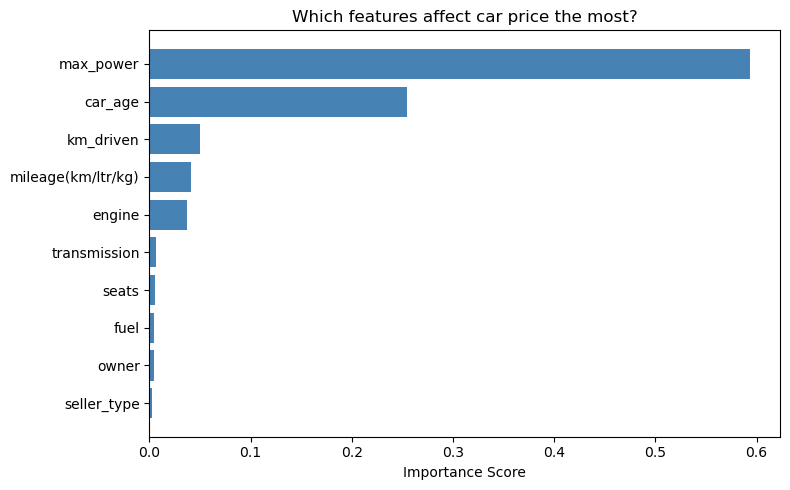

In [165]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature'    : X.columns,
    'Importance' : rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top Features:")
print(importance)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.title('Which features affect car price the most?')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [166]:
def predict_car_price(km_driven, fuel, seller_type,
                       transmission, owner, mileage,
                       engine, max_power, seats, car_age):
    
    input_data = pd.DataFrame([[km_driven, fuel, seller_type,
                                  transmission, owner, mileage,
                                  engine, max_power, seats, car_age]],
                               columns=X.columns)
    
    predicted_price = rf.predict(input_data)[0]
    print(f"Estimated Car Price: ₹ {predicted_price:,.0f}")
    return predicted_price

# Example 1 — 7 year old Diesel Manual car
print("Example 1:")
predict_car_price(
    km_driven=45000, fuel=1, seller_type=1,
    transmission=1, owner=0, mileage=23.4,
    engine=1248, max_power=74, seats=5, car_age=7
)

# Example 2 — 3 year old Petrol Automatic car  
print("Example 2:")
predict_car_price(
    km_driven=20000, fuel=2, seller_type=0,
    transmission=0, owner=0, mileage=18.5,
    engine=1500, max_power=120, seats=5, car_age=3
)

Example 1:
Estimated Car Price: ₹ 650,770
Example 2:
Estimated Car Price: ₹ 1,740,450


np.float64(1740449.99)

In [174]:
# Save model
joblib.dump(rf, 'car_price_model.pkl')
print("Model saved successfully!")

# Load and use later 
loaded_model = joblib.load('car_price_model.pkl')
y_pred_loaded = loaded_model.predict(X_test)
print("Loaded model R2:", round(r2_score(y_test, y_pred_loaded), 3))

Model saved successfully!
Loaded model R2: 0.92
